<a href="https://colab.research.google.com/github/adimika04-collab/Analisis-Regresi/blob/main/Proyek_Anreg_Mika_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving SuperMarket Analysis Proyek.csv to SuperMarket Analysis Proyek.csv
Jumlah Observasi: 1000
   Quantity     Sales
0         7  548.9715
1         5   80.2200
2         7  340.5255
3         8  489.0480
4         7  634.3785

=== STATISTIK DESKRIPTIF ===
          Quantity        Sales
count  1000.000000  1000.000000
mean      5.510000   322.966749
std       2.923431   245.885335
min       1.000000    10.678500
25%       3.000000   124.422375
50%       5.000000   253.848000
75%       8.000000   471.350250
max      10.000000  1042.650000

Korelasi Pearson
r      = 0.7055
p-value= 2.0639475196790557e-151


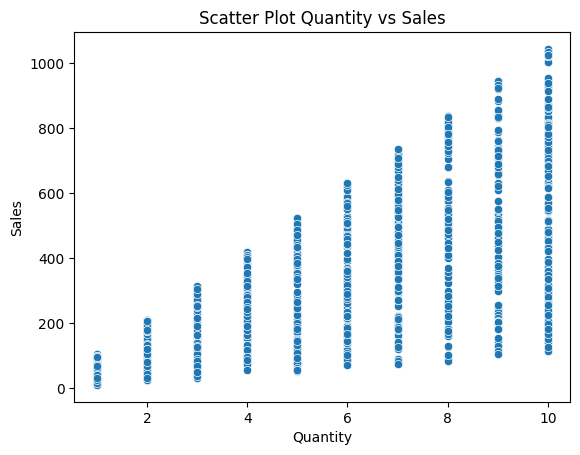


=== RINGKASAN MODEL REGRESI ===
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     989.0
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          2.06e-151
Time:                        01:12:16   Log-Likelihood:                -6579.0
No. Observations:                1000   AIC:                         1.316e+04
Df Residuals:                     998   BIC:                         1.317e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.99

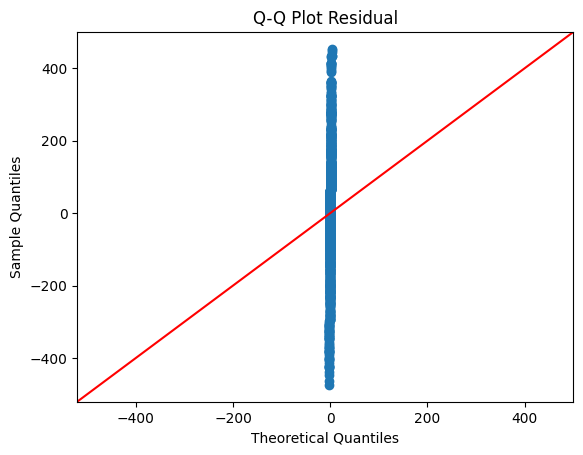


=== UJI BREUSCH–PAGAN ===
LM Statistic: 342.9461
p-value     : 1.4563325349761917e-76
Kesimpulan: Terdapat heteroskedastisitas


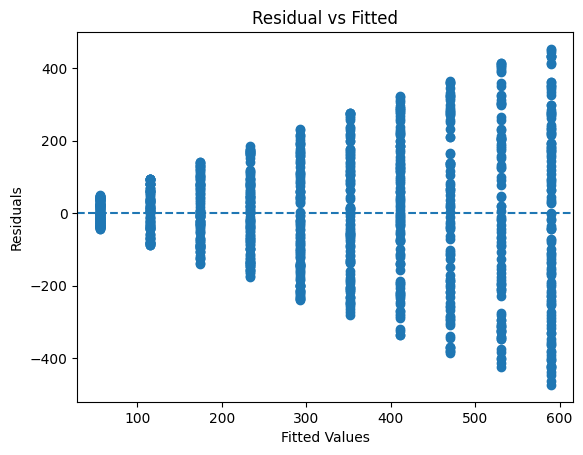


=== UJI AUTOKORELASI (Durbin–Watson) ===
DW Statistic: 1.9751
Kesimpulan: Tidak ada autokorelasi

=== INTERVAL KEPERCAYAAN 95% ===
                  0          1
const    -27.086076  19.099420
Quantity  55.636753  63.042041

=== HASIL PREDIKSI SALES ===
         mean  mean_ci_lower  mean_ci_upper
0  292.703657     281.721087     303.686226
1  470.721847     456.507358     484.936336
2  589.400641     569.565386     609.235896

File 'hasil_regresi_supermarket.csv' berhasil disimpan.


In [ ]:
# ==========================================================
# ANALISIS REGRESI LINEAR SEDERHANA
# DATASET : SuperMarket Analysis Proyek.csv
# X        : Quantity
# Y        : Sales
# ==========================================================

# =========================
# 1. IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# =========================
# 2. LOAD DATA
# =========================
from google.colab import files
uploaded = files.upload()

data = pd.read_csv("SuperMarket Analysis Proyek.csv")

# Pilih variabel & bersihkan data
data = data[['Quantity', 'Sales']].dropna()

print("Jumlah Observasi:", len(data))
print(data.head())

# =========================
# 3. ANALISIS DESKRIPTIF
# =========================
print("\n=== STATISTIK DESKRIPTIF ===")
print(data.describe())

# Korelasi Pearson
r, p_corr = pearsonr(data['Quantity'], data['Sales'])
print("\nKorelasi Pearson")
print("r      =", round(r,4))
print("p-value=", p_corr)

# =========================
# 4. VISUALISASI AWAL
# =========================
plt.figure()
sns.scatterplot(x='Quantity', y='Sales', data=data)
plt.title("Scatter Plot Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

# =========================
# 5. REGRESI LINEAR SEDERHANA
# =========================
X = sm.add_constant(data['Quantity'])
Y = data['Sales']

model = sm.OLS(Y, X).fit()

print("\n=== RINGKASAN MODEL REGRESI ===")
print(model.summary())

# Ambil parameter (TANPA WARNING)
intercept = model.params['const']
slope = model.params['Quantity']
r_squared = model.rsquared
p_value_slope = model.pvalues['Quantity']

print("\nPersamaan Regresi:")
print(f"Sales = {intercept:.4f} + {slope:.4f} × Quantity")

print("R-squared:", round(r_squared,4))

# =========================
# 6. UJI NORMALITAS RESIDUAL
# =========================
residuals = model.resid

stat, p_normal = shapiro(residuals)

print("\n=== UJI NORMALITAS (Shapiro–Wilk) ===")
print("Statistic:", round(stat,4))
print("p-value  :", p_normal)

if p_normal > 0.05:
    print("Kesimpulan: Residual berdistribusi normal")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal")

# Q-Q Plot
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot Residual")
plt.show()

# =========================
# 7. UJI HETEROSKEDASTISITAS
# =========================
bp_test = het_breuschpagan(residuals, X)

print("\n=== UJI BREUSCH–PAGAN ===")
print("LM Statistic:", round(bp_test[0],4))
print("p-value     :", bp_test[1])

if bp_test[1] > 0.05:
    print("Kesimpulan: Tidak ada heteroskedastisitas")
else:
    print("Kesimpulan: Terdapat heteroskedastisitas")

# Plot residual vs fitted
plt.figure()
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

# =========================
# 8. UJI AUTOKORELASI
# =========================
dw = durbin_watson(residuals)

print("\n=== UJI AUTOKORELASI (Durbin–Watson) ===")
print("DW Statistic:", round(dw,4))

if 1.5 < dw < 2.5:
    print("Kesimpulan: Tidak ada autokorelasi")
else:
    print("Kesimpulan: Ada indikasi autokorelasi")

# =========================
# 9. INTERVAL KEPERCAYAAN
# =========================
print("\n=== INTERVAL KEPERCAYAAN 95% ===")
print(model.conf_int())

# =========================
# 10. PREDIKSI
# =========================
quantity_pred = pd.DataFrame({
    'const': 1,
    'Quantity': [5, 8, 10]
})

prediction = model.get_prediction(quantity_pred)
prediction_df = prediction.summary_frame(alpha=0.05)

print("\n=== HASIL PREDIKSI SALES ===")
print(prediction_df[['mean', 'mean_ci_lower', 'mean_ci_upper']])

# =========================
# 11. SIMPAN OUTPUT
# =========================
hasil = pd.DataFrame({
    'Komponen': [
        'Intercept', 'Slope',
        'R-squared',
        'p-value slope',
        'p-value normalitas',
        'p-value heteroskedastisitas'
    ],
    'Nilai': [
        intercept,
        slope,
        r_squared,
        p_value_slope,
        p_normal,
        bp_test[1]
    ]
})

hasil.to_csv("hasil_regresi_supermarket.csv", index=False)
print("\nFile 'hasil_regresi_supermarket.csv' berhasil disimpan.")